Dataset -> Socio-Economic of Indonesia in 2021 (Kabupaten/Kota) — berisi kemiskinan, PDRB, harapan hidup, lama sekolah, dan pengeluaran per kapita. Sangat cocok untuk PCA dan clustering.

1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

2. Mount Google Drive

In [2]:
df = pd.read_csv('2021socio_economic_indonesia.csv')

3. Membaca Dataset dari Google Drive

In [3]:
df = pd.read_csv('2021socio_economic_indonesia.csv')
df.head()

,province,cities_reg,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
0,Aceh,Simeulue,18.98,2.275,65.240,9.48,7148
1,Aceh,Aceh Singkil,20.36,2.425,67.355,8.68,8776
2,Aceh,Aceh Selatan,13.18,5.531,64.360,8.88,8180
3,Aceh,Aceh Tenggara,13.41,5.063,68.155,9.67,8030
4,Aceh,Aceh Timur,14.45,10.616,68.705,8.21,8577


4. Menampilkan Informasi Dataset

In [4]:
print("Ukuran Dataset:")
print(df.shape)

print("\nNama Kolom:")
print(df.columns)

print("\n5 Data Pertama:")
display(df.head())

Ukuran Dataset:
(514, 7)

Nama Kolom:
Index(['province', 'cities_reg', 'poorpeople_percentage', 'reg_gdp',
       'life_exp', 'avg_schooltime', 'exp_percap'],
      dtype='object')

5 Data Pertama:


,province,cities_reg,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
0,Aceh,Simeulue,18.98,2.275,65.240,9.48,7148
1,Aceh,Aceh Singkil,20.36,2.425,67.355,8.68,8776
2,Aceh,Aceh Selatan,13.18,5.531,64.360,8.88,8180
3,Aceh,Aceh Tenggara,13.41,5.063,68.155,9.67,8030
4,Aceh,Aceh Timur,14.45,10.616,68.705,8.21,8577


5. Mengecek Missing Value

In [5]:
df.isnull().sum()

province                 0
cities_reg               0
poorpeople_percentage    0
reg_gdp                  0
life_exp                 0
avg_schooltime           0
exp_percap               0
dtype: int64

6. Ambil Seluruh Variabel Numerik

PCA hanya menggunakan data numerik.

In [6]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Jumlah Variabel Numerik:")
print(numeric_df.shape)

display(numeric_df.head())

Jumlah Variabel Numerik:
(514, 5)


,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
0,18.98,2.275,65.240,9.48,7148
1,20.36,2.425,67.355,8.68,8776
2,13.18,5.531,64.360,8.88,8180
3,13.41,5.063,68.155,9.67,8030
4,14.45,10.616,68.705,8.21,8577


7. Statistik Deskriptif

In [7]:
numeric_df.describe()

,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
count,514.000000,514.000000,514.000000,514.000000,514.000000
mean,12.273152,34.798333,69.619076,8.436615,10324.787938
std,7.458703,84.155498,3.455911,1.630842,2717.144186
min,2.380000,1.042000,55.370000,1.420000,3976.000000
25%,7.150000,5.587500,67.336250,7.510000,8574.000000
50%,10.455000,13.068500,69.922500,8.305000,10196.500000
75%,14.887500,28.849500,72.018750,9.337500,11719.000000
max,41.660000,819.000000,77.855000,12.830000,23888.000000


8. Heatmap Korelasi

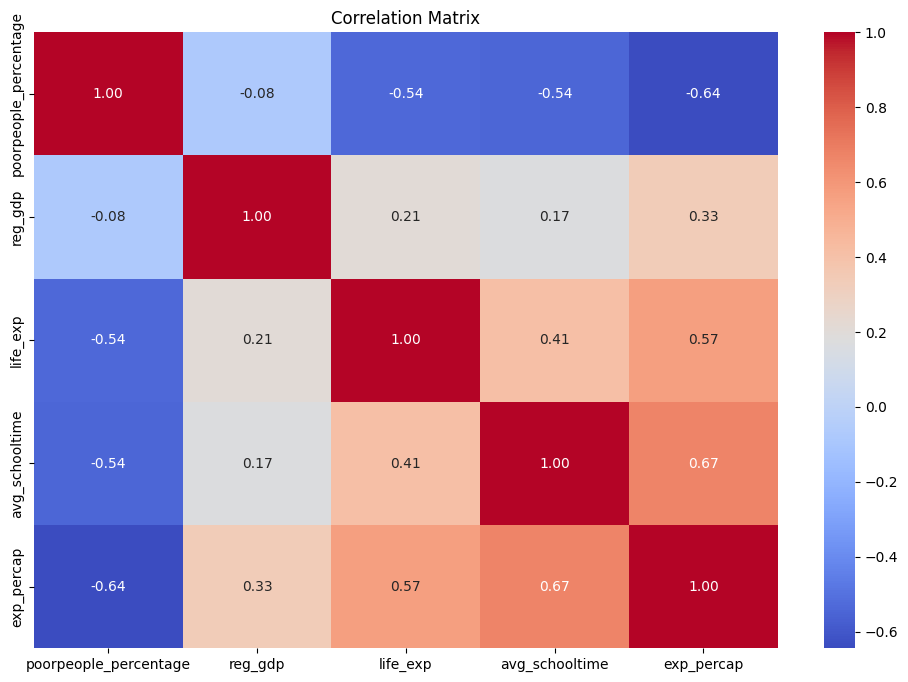

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

9. Visualisasi Data Awal (Sebelum PCA)

Menggunakan dua variabel numerik pertama agar tidak error.

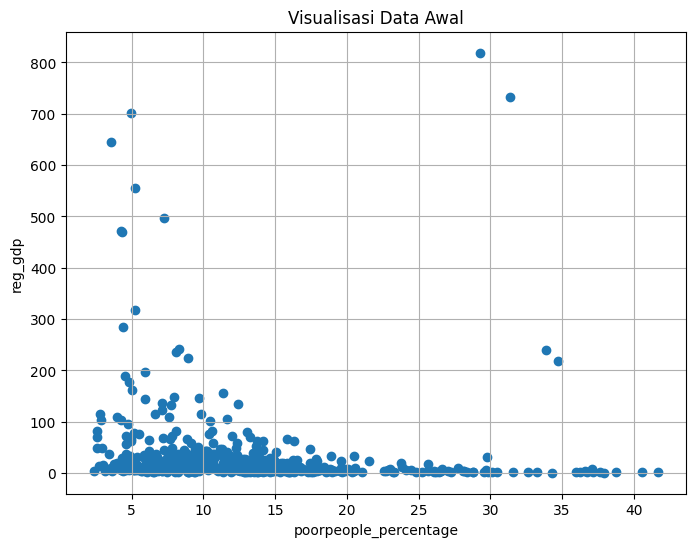

In [9]:
x_col = numeric_df.columns[0]
y_col = numeric_df.columns[1]

plt.figure(figsize=(8,6))

plt.scatter(
    numeric_df[x_col],
    numeric_df[y_col]
)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("Visualisasi Data Awal")

plt.grid(True)
plt.show()

10. Standardisasi Data

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(numeric_df)

print(X_scaled.shape)

(514, 5)


11. Menentukan Jumlah Komponen PCA

In [11]:
pca_full = PCA()

pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print(explained_variance)

[0.55691782 0.19207116 0.11938847 0.079426   0.05219655]


12. Scree Plot

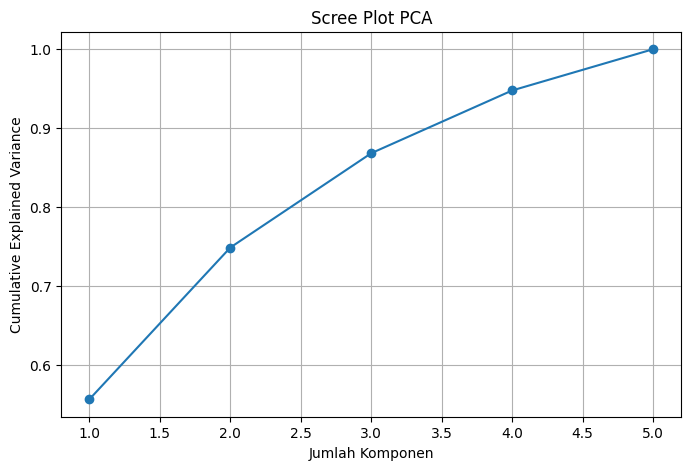

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot PCA")

plt.grid(True)
plt.show()

13. PCA Menjadi 2 Komponen

In [13]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

14. DataFrame Hasil PCA

In [14]:
pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

display(pca_df.head())

,PC1,PC2
0,-1.418801,-0.184025
1,-1.141943,-0.048213
2,-1.119047,-0.309436
3,-0.437900,-0.417617
4,-0.735745,-0.183995


15. Variansi yang Dijelaskan

In [15]:
print("Explained Variance Ratio")

for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.4f}")

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio
PC1: 0.5569
PC2: 0.1921

Total Variance Explained:
0.7489889778499944


16. Visualisasi Hasil PCA

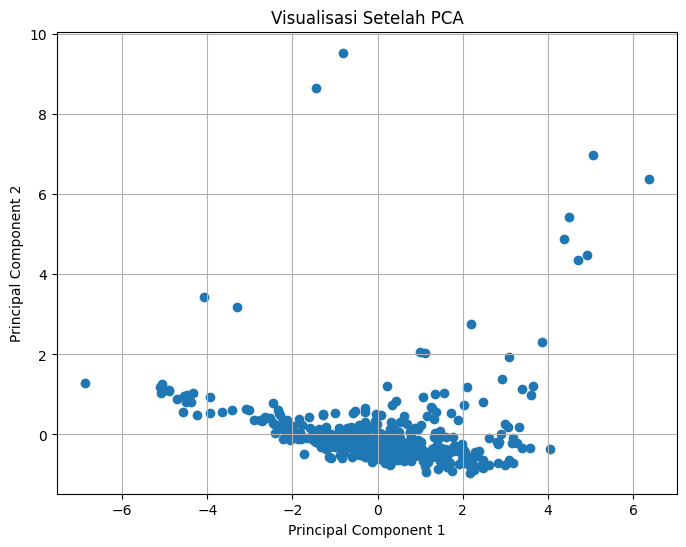

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('Visualisasi Setelah PCA')

plt.grid(True)
plt.show()

17. Perbandingan Sebelum dan Sesudah PCA

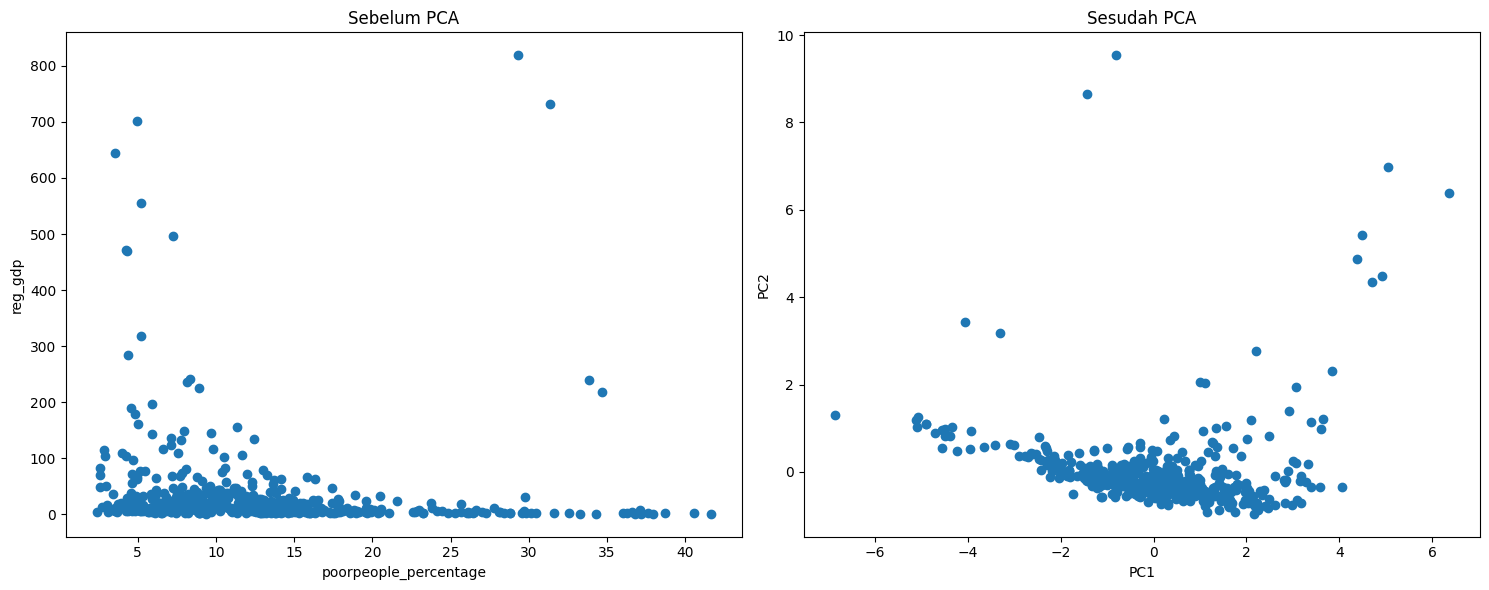

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15,6))

# Sebelum PCA
ax[0].scatter(
    numeric_df[x_col],
    numeric_df[y_col]
)

ax[0].set_title("Sebelum PCA")
ax[0].set_xlabel(x_col)
ax[0].set_ylabel(y_col)

# Sesudah PCA
ax[1].scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

ax[1].set_title("Sesudah PCA")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

18. Loading Factor

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=numeric_df.columns
)

display(loadings)

,PC1,PC2
poorpeople_percentage,-0.484424,0.312210
reg_gdp,0.218616,0.937602
life_exp,0.452218,-0.038972
avg_schooltime,0.474153,-0.137679
exp_percap,0.536859,0.054338


19. Visualisasi Loading Factor

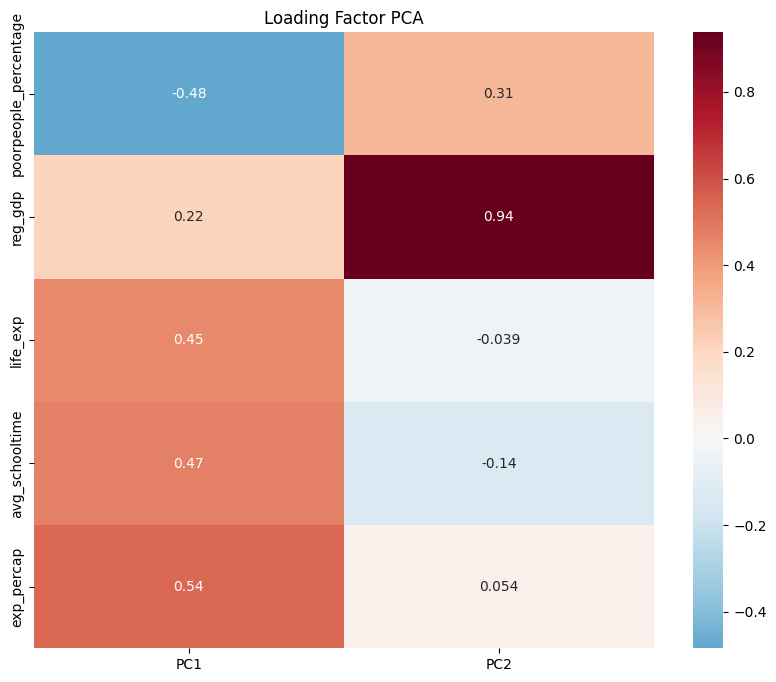

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    loadings,
    annot=True,
    cmap='RdBu_r',
    center=0
)

plt.title("Loading Factor PCA")
plt.show()